In [ ]:
# Prepare Data
import os
import sys
import yaml
import torch
import pickle
import warnings
import setproctitle
import numpy as np
import sympy as sp
import pandas as pd
import torch.utils.data as D
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from IPython.display import display
from copy import deepcopy
from scipy.optimize import minimize
from nd2.model import NDformer
from nd2.utils import init_logger
from nd2.search import MCTS
from nd2.GDExpr import GDExpr
from nd2.dataset import Dataset
from nd2.utils import AttrDict, get_fig, seed_all
from nd2.search.reward_solver import RewardSolver, RolloutRewardSolver

warnings.filterwarnings("ignore", category=RuntimeWarning)
seed_all(42)


df = pd.read_csv('./data/gene/data2.csv', index_col=0)
data = df.values

T = data.shape[0] - 1 # 17 - 1 = 16
V = data.shape[1] # 7
E = V * (V - 1) # 42
A = 1 - np.eye(V) # (V, V)
G = np.stack(np.nonzero(A), axis=-1) # (E, 2)

x = np.array(data[:-1, :]) # (T, V)
dx = np.diff(data, axis=0) # (T, V)
data = dict(V=V, E=E, A=A, G=G, dx=dx, x=x)

In [84]:
import pandas as pd

df = pd.read_csv('./data/gene/2010.Spellman98_cdc15.flt.knn.avg.pcl', sep='\t')
df.drop(columns=['YORF', 'NAME', 'GWEIGHT'], inplace=True)
df.columns = [i[-7:-4] for i in df.columns]
df.drop(columns='min', inplace=True)

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances
import numpy as np

# 示例 DataFrame

# 1. 标准化特征（可选，但推荐）
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# 2. 聚类（KMeans 示例）
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X_scaled)

# 3. 将标签添加回 DataFrame
df['cluster'] = labels
df = df.groupby('cluster').mean().T
df.columns = [f'Type{i+1}' for i in df.columns]
df.columns.name = None
df.index.name = 'time'
df -= df.mean()

df.to_csv('./data/gene/data2.csv')

data = df.values

T = data.shape[0] - 1 # 17 - 1 = 16
V = data.shape[1] # 7
E = V * (V - 1) # 42
A = 1 - np.eye(V) # (V, V)
G = np.stack(np.nonzero(A), axis=-1) # (E, 2)

x = np.array(data[:-1, :]) # (T, V)
dx = np.diff(data, axis=0) # (T, V)
data = dict(V=V, E=E, A=A, G=G, dx=dx, x=x)

In [85]:
reward_solver = RewardSolver(
    Xv={'x': data['x']},
    Xe={},
    A=data['A'],
    G=data['G'],
    Y=data['dx']
)

def evaluate(expr, N=10, x0=None):
    prefix = GDExpr.sympy2prefix(GDExpr.parse_expr(expr), 'node', reindex=False, keep_coeff=True)
    prefix_with_coef = reward_solver.solve(prefix, x0=x0)[1]
    single_step = reward_solver.evaluate(prefix_with_coef)

    true = np.concatenate([data['x'], data['x'][(-1,), :] + data['dx'][(-1,), :]], axis=0)
    pred = [data['x'][[0]]]
    for t in range(T):
        for n in range(N):
            y = GDExpr.eval(prefix_with_coef, {**data, 'x': pred[-1]}, [], strict=False)
            x_ = pred[-1] + y / N
            x_ = x_.clip(-1, 1)
            pred.append(x_)
    pred_all = np.concatenate(pred, axis=0)
    pred = pred_all[::N]
    R2 = 1 - np.sum((pred - true) ** 2) / np.sum((true - np.mean(true)) ** 2)
    RMSE = np.sqrt(np.mean((pred - true) ** 2))
    sMAPE = 2 * np.mean(np.abs(pred - true) / (np.abs(pred) + np.abs(true)).clip(1e-6))
    rollout = {
        'R2': R2,
        'RMSE': RMSE,
        'sMAPE': sMAPE,
        'time': np.arange(T+1),
        'time_all': np.arange(N*T+1)/N,
        'true': true,
        'pred_all': pred_all
    }
    return prefix_with_coef, single_step, rollout

In [38]:
RESULT = {}

Rollout reward: R2=-0.0587, RMSE=0.3182, sMAPE=151.55%


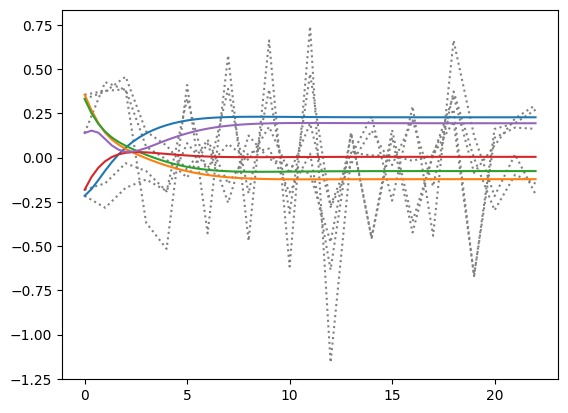

In [88]:
expr = '<Cv> - <Cv> * x + aggr(<Ce> * regular(sour(x/<Cv>), 2))'
prefix_with_coef, single_step, rollout = evaluate(expr, N=3)

# print(f'Single-step reward: R2={single_step["R2"]:.4f}, RMSE={single_step["RMSE"]:.4f}, sMAPE={single_step["sMAPE"]:.2%}')
print(f'Rollout reward: R2={rollout["R2"]:.4f}, RMSE={rollout["RMSE"]:.4f}, sMAPE={rollout["sMAPE"]:.2%}')

plt.plot(rollout['time'], rollout['true'], ':', label='True', color='gray')
for i in range(V):
    plt.plot(rollout['time_all'], rollout['pred_all'][:, i], label='Pred', color=f'C{i}')

In [89]:
RESULT['R_N5_CDC15'] = {**rollout, 'prefix_with_coef': prefix_with_coef}

In [69]:
prefix_with_coef = ['sub', 'add', np.array([-0.2593862 , -0.26029985, -0.32649167, -0.22465153, -0.2934855 , -0.26658694, -0.22642833, -0.25409986, -0.25305952, -0.28991806, -0.31304446, -0.28434057, -0.29669137, -0.28884947, -0.30126442, -0.30221201, -0.27661082, -0.22093319, -0.24928243, -0.23797271]), 'mul', np.array([-0.55464397, -1.72863928, -0.23506253, -0.42179539, -0.23171673, -1.55766998, -0.36816139, -0.42564366, -1.04442444, -0.74891671, -1.18744728, -0.12664163, -1.44110985, -1.22507644, -1.74218468, -0.76446795, -1.35524492, -0.34472469, -1.30114063, -0.73374286]), 'x', 'mul', np.float64(-0.5699267764296723), 'sigmoid', 'aggr', 'mul', np.array([ 1.57901840e+00, -3.73228080e+00, -6.09447769e-01, -1.04457675e+00,  8.51439703e-01,  5.27057082e-01, -3.79957543e-01,  8.71009465e-02,  2.43643328e-01, -8.78845440e-01, -4.89786439e-01,  8.94831606e-01, -2.40883803e-01, -6.34435282e-01,  9.81806511e-01,  4.39129268e-01,  1.67308771e+00, -1.50878674e+00, -1.04130203e+00,  4.08629279e-01, -8.40338747e-01,  6.97206015e-01, -2.83964788e+00, -8.40927598e-01, -9.21054444e-01, -1.13218086e+00, -4.13313625e-01,  2.02658302e-01,  6.06139330e-01, -9.51247050e-02, -1.25263761e+00,  1.58984946e-01,  2.74910372e-02,  8.76601072e-01,  9.55044888e-01, -3.29701893e-02, -9.65674780e-01, -8.42990810e-01,  2.61121266e+00, -4.85948524e-01,  4.82904043e-01,  7.31234078e-01,  8.58958143e-01, -2.28576488e+00, -4.60639009e-02, -1.08752101e+00, -1.01030513e+00, -1.69131158e+00, -1.49386885e+00,  5.22927354e+00, -4.43914857e-01, -4.25251726e-02,  1.75092600e-01,  1.44240646e+00, -1.27041098e+00,  2.82315125e-01,  4.54043439e-01, -8.88755242e-01, -9.23223570e-01,  1.30831108e+00, -4.31193050e-01, -1.93969417e+00, -1.94399421e+00, -2.67899788e-01, -1.35207950e+00, -8.44584555e-01, -7.41989869e-02,  1.05255690e+00,  1.33401257e-01,  1.14794078e+00,  1.06147705e+00,  1.17140875e+00, -4.81186833e-02, -1.92646265e+00,  7.67701956e-01,  1.37194211e+00,  3.67079631e-01,  1.79357611e+00,  6.01324639e-01,  3.31462489e-01,  1.38810786e+00, -8.00919850e-02, -2.64228034e+00, -6.23456451e-01,  1.11666134e+00, -2.66133894e-01, -7.65254600e-01, -9.47783295e-01,  1.72921601e+00,  1.91852576e+00, -7.82962422e-01,  2.60471028e-01, -8.83555752e-01,  4.20145515e-01,  1.75768325e-01,  1.03655656e+00,  9.65227291e-03,  1.81232387e+00, -1.53993674e+00, -2.84456521e+00, -1.56339799e+00, -2.02246412e+00, -2.57832874e+00, -1.94825902e+00, -7.53232344e-02, -1.90576699e+00, -1.41428862e+00, -6.41539457e-01, -3.40848657e-01,  4.38159504e-01, -1.93176116e+00, -1.01205947e+00,  4.03536345e-01, -2.36269483e+00, -3.25046202e+00,  2.29854298e-01,  1.90167144e+00,  1.79951636e+00, -3.25571899e-01,  1.06886468e+00, -4.37717781e-02,  2.22263135e-01,  9.67700172e-01, -2.39634183e+00,  1.00190949e-01, -2.45948536e-02,  2.07356496e-02,  8.30790184e-01, -7.01955225e-01, -9.37232610e-01, -3.06104945e-01, -1.07667270e+00, -4.65551113e-01, -1.67687810e+00,  6.19686550e-01,  6.16072096e-01,  1.50159559e-01,  3.39761426e-01, -6.87422974e-01,  1.00170633e+00, -5.13744491e-01, -3.57032797e-01, -4.98985893e-01,  6.28945608e-01, -2.00127888e+00,  7.32871395e-01, -1.49316167e+00, -1.44672584e+00,  4.38072736e-01, -3.94771411e-01, -4.59850709e-01,  8.23415983e-01, -3.67229667e-01, -1.88956083e-01,  9.55082681e-01,  1.07317883e+00,  1.07464626e+00,  5.39493244e-01,  4.00830331e-01, -1.12700044e+00, -1.54705015e+00, -1.66732511e+00,  5.60221928e-01, -1.23300232e+00, -2.85050833e-01, -9.73680397e-01,  6.68777586e-01, -9.22061687e-01, -1.60957881e+00,  5.50256893e-01, -1.83719981e+00, -6.82725999e-01, -1.92411801e+00, -1.90966655e+00, -1.13521992e-01, -2.05469712e+00, -1.01829498e+00, -3.79579065e-01, -4.94914724e-01,  1.86540291e+00,  2.14655609e+00, -1.92346971e+00,  8.47613088e-01,  6.33598523e-01, -4.17712595e-01, -1.36044058e+00,  7.07915213e-02, -9.88552005e-02, -6.12618639e-01,  3.40386983e-02, -3.39106006e-01, -6.19918543e-01,  2.02884852e-01,  1.01554790e-01, -7.27594101e-01,  2.55083725e+00, -1.66990372e+00, -4.49525068e-01,  4.46050768e-01, -4.92320276e-01, -1.74473079e+00,  3.56059097e+00, -8.75917336e-01,  2.79206629e+00,  9.89172147e-01,  9.47685679e-01,  7.44826220e-01,  2.85834055e+00, -1.36655845e+00, -2.69246304e-01, -1.09580911e+00,  6.17379878e-01, -1.35688366e+00, -3.34683273e-01,  1.72245814e+00, -8.17877962e-01, -7.19536708e-01, -7.92077158e-01,  4.02934035e-01, -3.22504881e-01,  2.35400018e+00,  2.17107341e+00,  1.07378747e-01, -1.98055432e-01, -2.37916717e-01,  1.02911899e+00, -4.34408199e-01,  4.30490464e-01,  1.09294747e+00, -3.39604345e-01, -1.64966399e+00, -1.55929878e+00, -1.99016559e+00, -6.06136042e-01, -3.30262749e+00, -8.13785057e-01, -2.08529514e+00, -1.28295400e+00, -4.08112274e-01, -1.29970543e+00,  5.42628190e-01, -2.82039236e-01, -1.02426976e+00, -7.68960579e-01, -1.58658159e+00, -2.29356595e+00,  1.05758626e+00, -6.08145898e-01,  1.37041016e-01,  9.01642980e-01,  3.52769756e+00, -1.02273098e+00,  1.10682165e+00, -6.34900361e-01, -3.26340267e-01, -4.35820182e-01, -1.14232602e+00, -1.32572892e-01, -2.15532435e+00,  2.15177629e+00,  3.36213418e-03,  5.23778765e-01,  6.23652886e-02, -1.13523740e-02,  4.16082719e-01, -1.27003538e+00, -4.22946400e-01, -5.95296845e-01, -1.08691644e+00, -2.20260168e+00,  1.51009690e+00, -2.84642237e-02,  1.22145339e+00,  1.24593986e+00, -1.07491398e+00, -1.16490168e+00,  2.65436236e+00,  9.38063666e-01,  8.81096945e-01,  1.86742704e-01, -5.09827912e-01,  8.87375624e-01, -4.26776191e-01, -1.94529950e+00, -1.53633674e+00,  3.65068224e-01, -1.01709890e+00, -1.69875747e-01, -1.31911865e+00, -8.68872490e-01,  1.46545761e+00, -1.42530632e-01, -8.48659345e-02,  8.49264292e-01,  2.81379992e-01,  1.92580221e+00, -1.14048132e+00, -1.00888897e-01, -1.35585253e+00, -3.66434401e-01,  1.07478847e+00,  1.17653822e+00,  1.04028485e+00, -2.09271540e+00,  6.36415994e-01, -2.20551582e+00, -3.20251975e-01, -7.74286645e-01, -1.38611737e-01, -1.37168281e+00,  4.08700507e-01, -1.43625709e+00, -1.54224370e+00, -1.77005649e+00, -2.28031501e+00, -6.80112007e-01,  5.97062288e-01,  2.11245092e+00, -4.93239827e-01,  4.21035822e-01, -1.33541015e-01,  5.67493710e-01, -8.43056260e-01, -1.00254792e+00,  2.18876597e-01, -4.39912414e-01,  3.55610940e-02, -5.58812959e-01,  2.45401567e-01, -9.50814277e-01,  2.45390820e-01,  1.45572718e+00,  6.93159175e-01,  2.76760440e-01,  2.78473304e-01, -1.46970569e+00,  7.12962301e-01,  7.00829188e-01, -2.46021272e+00, -1.84596253e+00,  1.78328696e+00,  2.70405669e-01, -3.77738221e-01, -1.49110467e+00, -9.79105538e-01, -1.78277325e+00,  1.19202901e+00, -2.81921477e-02, -1.11946159e+00,  2.19134168e-01,  1.39806479e-01,  1.18075065e-01,  1.84553268e+00, -1.22918413e+00, -2.00722354e+00,  7.20508853e-01, -6.99631623e-01, -3.54279295e-01, -6.26157907e-01,  1.27448728e-01, -1.96453926e+00,  8.95621959e-01, -2.31955788e-01,  9.09599513e-01,  9.51267330e-01,  1.64324898e+00,  1.74067096e+00,  1.08879840e+00,  1.56882261e+00,  3.56335077e-01, -1.43933856e-01,  5.77889547e-01,  4.02596894e-01,  7.73705289e-01,  4.02467481e-01, -3.30749344e-01, -9.59431403e-01,  1.44607110e+00,  2.49293559e-01,  2.31258566e+00]), 'sour', 'x']

Rollout reward: R2=0.1147, RMSE=0.2910, sMAPE=148.43%


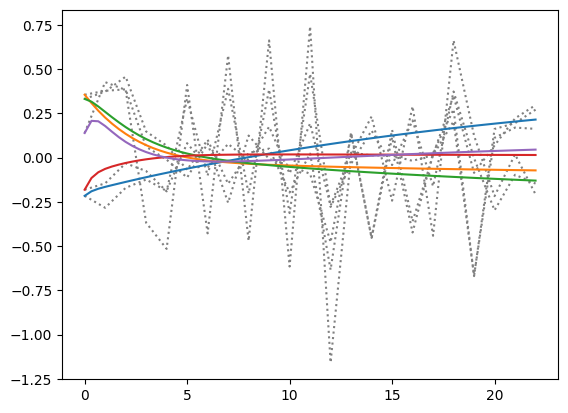

In [98]:
expr = '<Cv> + <Cv> * x - <C> * sigmoid(aggr(<Ce> * sour(x)))'
prefix_with_coef, single_step, rollout = evaluate(expr, N=3)

# print(f'Single-step reward: R2={single_step["R2"]:.4f}, RMSE={single_step["RMSE"]:.4f}, sMAPE={single_step["sMAPE"]:.2%}')
print(f'Rollout reward: R2={rollout["R2"]:.4f}, RMSE={rollout["RMSE"]:.4f}, sMAPE={rollout["sMAPE"]:.2%}')

plt.plot(rollout['time'], rollout['true'], ':', label='True', color='gray')
for i in range(V):
    plt.plot(rollout['time_all'], rollout['pred_all'][:, i], label='Pred', color=f'C{i}')

In [99]:
RESULT['C_N5_CDC15'] = {**rollout, 'prefix_with_coef': prefix_with_coef}

In [ ]:
sns.barplot(pd.DataFrame({'Existing': existing['RMSEs'], 'Discovered': discovered['RMSEs'],}, index=[f'Species {i+1}' for i in range(V)]), 
            palette=['#d63031', '#0984e3'], ax=axes[0], capsize=0.1, err_kws={'linewidth':1.0, 'color':'black'}, edgecolor='black', width=0.3)
axes[0].set_ylabel('RMSE', labelpad=0)
axes[0].tick_params('y', direction='in', length=2.0, pad=1.0)
axes[0].tick_params('x', length=0.0, pad=1.0)
axes[0].grid('on', alpha=0.2, dashes=[3, 1], zorder=-1)
# formatter = ScalarFormatter(useMathText=True)
# formatter.set_powerlimits((-1, 1))
# axes[0].yaxis.set_major_formatter(formatter)
# axes[0].yaxis.offsetText.set_fontsize(5)
axes[0].text(0.5, 0.5, f'{1- discovered['RMSEs'].mean() / existing['RMSEs'].mean():.2%}', ha='center', va='center', transform=axes[0].transAxes, fontsize=14, color='black')

sns.barplot(pd.DataFrame({'Existing': existing['sMAPEs'], 'Discovered': discovered['sMAPEs'],}, index=[f'Species {i+1}' for i in range(V)]),
            palette=['#d63031', '#0984e3'], ax=axes[1], capsize=0.1, err_kws={'linewidth':1.0, 'color':'black'}, edgecolor='black', width=0.3)
axes[1].set_ylabel('sMAPE', labelpad=0)
axes[1].tick_params('y', direction='in', length=2.0, pad=1.0)
axes[1].tick_params('x', length=0.0, pad=1.0)
axes[1].grid('on', alpha=0.2, dashes=[3, 1], zorder=-1)
axes[1].yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
axes[1].text(0.5, 0.5, f'{1- discovered['sMAPEs'].mean() / existing['sMAPEs'].mean():.2%}', ha='center', va='center', transform=axes[1].transAxes, fontsize=14, color='black')

fig.suptitle('High nutrient concentration')


# from io import BytesIO
# buffer = BytesIO()
# plt.rcParams['svg.fonttype'] = 'none'
# fig.savefig(buffer, dpi=300, transparent=False, format='svg')
# svg_file = buffer.getvalue().decode()
# svg_file = re.sub(r'font:\s*([0-9.]+)px (\'.*\')', r'font-size:\1px; font-family:\2;', svg_file)
# svg_file = re.sub(r'font: (?:oblique|italic) ([0-9.]+)px (\'.*\')', r'font-size:\1px; font-style:italic; font-family: \2;', svg_file)
# svg_file = re.sub(r"^(.*)font-family: 'DejaVu Sans';(.*)π(.*)$", r"\1font-family: 'Symbol';\2p\3", svg_file, flags=re.M)
# svg_file = re.sub('DejaVu Sans', 'Arial', svg_file)
# with open('../stuff/population-comparison-high.svg', 'wb') as f:
#     f.write(svg_file.encode('utf-8'))

In [118]:
RESULT['R_N20_CDC15'].keys()

dict_keys(['R2', 'RMSE', 'sMAPE', 'time', 'time_all', 'true', 'pred_all', 'prefix_with_coef'])

In [124]:
_RMSE = np.sqrt(np.mean(np.square(RESULT['R_N5_CDC15']['true'] - RESULT['R_N5_CDC15']['pred_all'][::N]), axis=0))
_RMSE

array([0.23034991, 0.26120995, 0.25877375, 0.23624069, 0.51202849])

In [157]:
RESULT['R_N20_CDC15']['sMAPE']

np.float64(1.370529405455581)

/tmp/ipykernel_3658399/1623969798.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(result, x='model', y='value', palette=['#d63031', '#0984e3'], ax=axes[3], capsize=0.1, err_kws={'linewidth':1.0, 'color':'black'}, edgecolor='black', width=0.3)
/tmp/ipykernel_3658399/1623969798.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(result, x='model', y='value', palette=['#d63031', '#0984e3'], ax=axes[4], capsize=0.1, err_kws={'linewidth':1.0, 'color':'black'}, edgecolor='black', width=0.3)
/tmp/ipykernel_3658399/1623969798.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` 

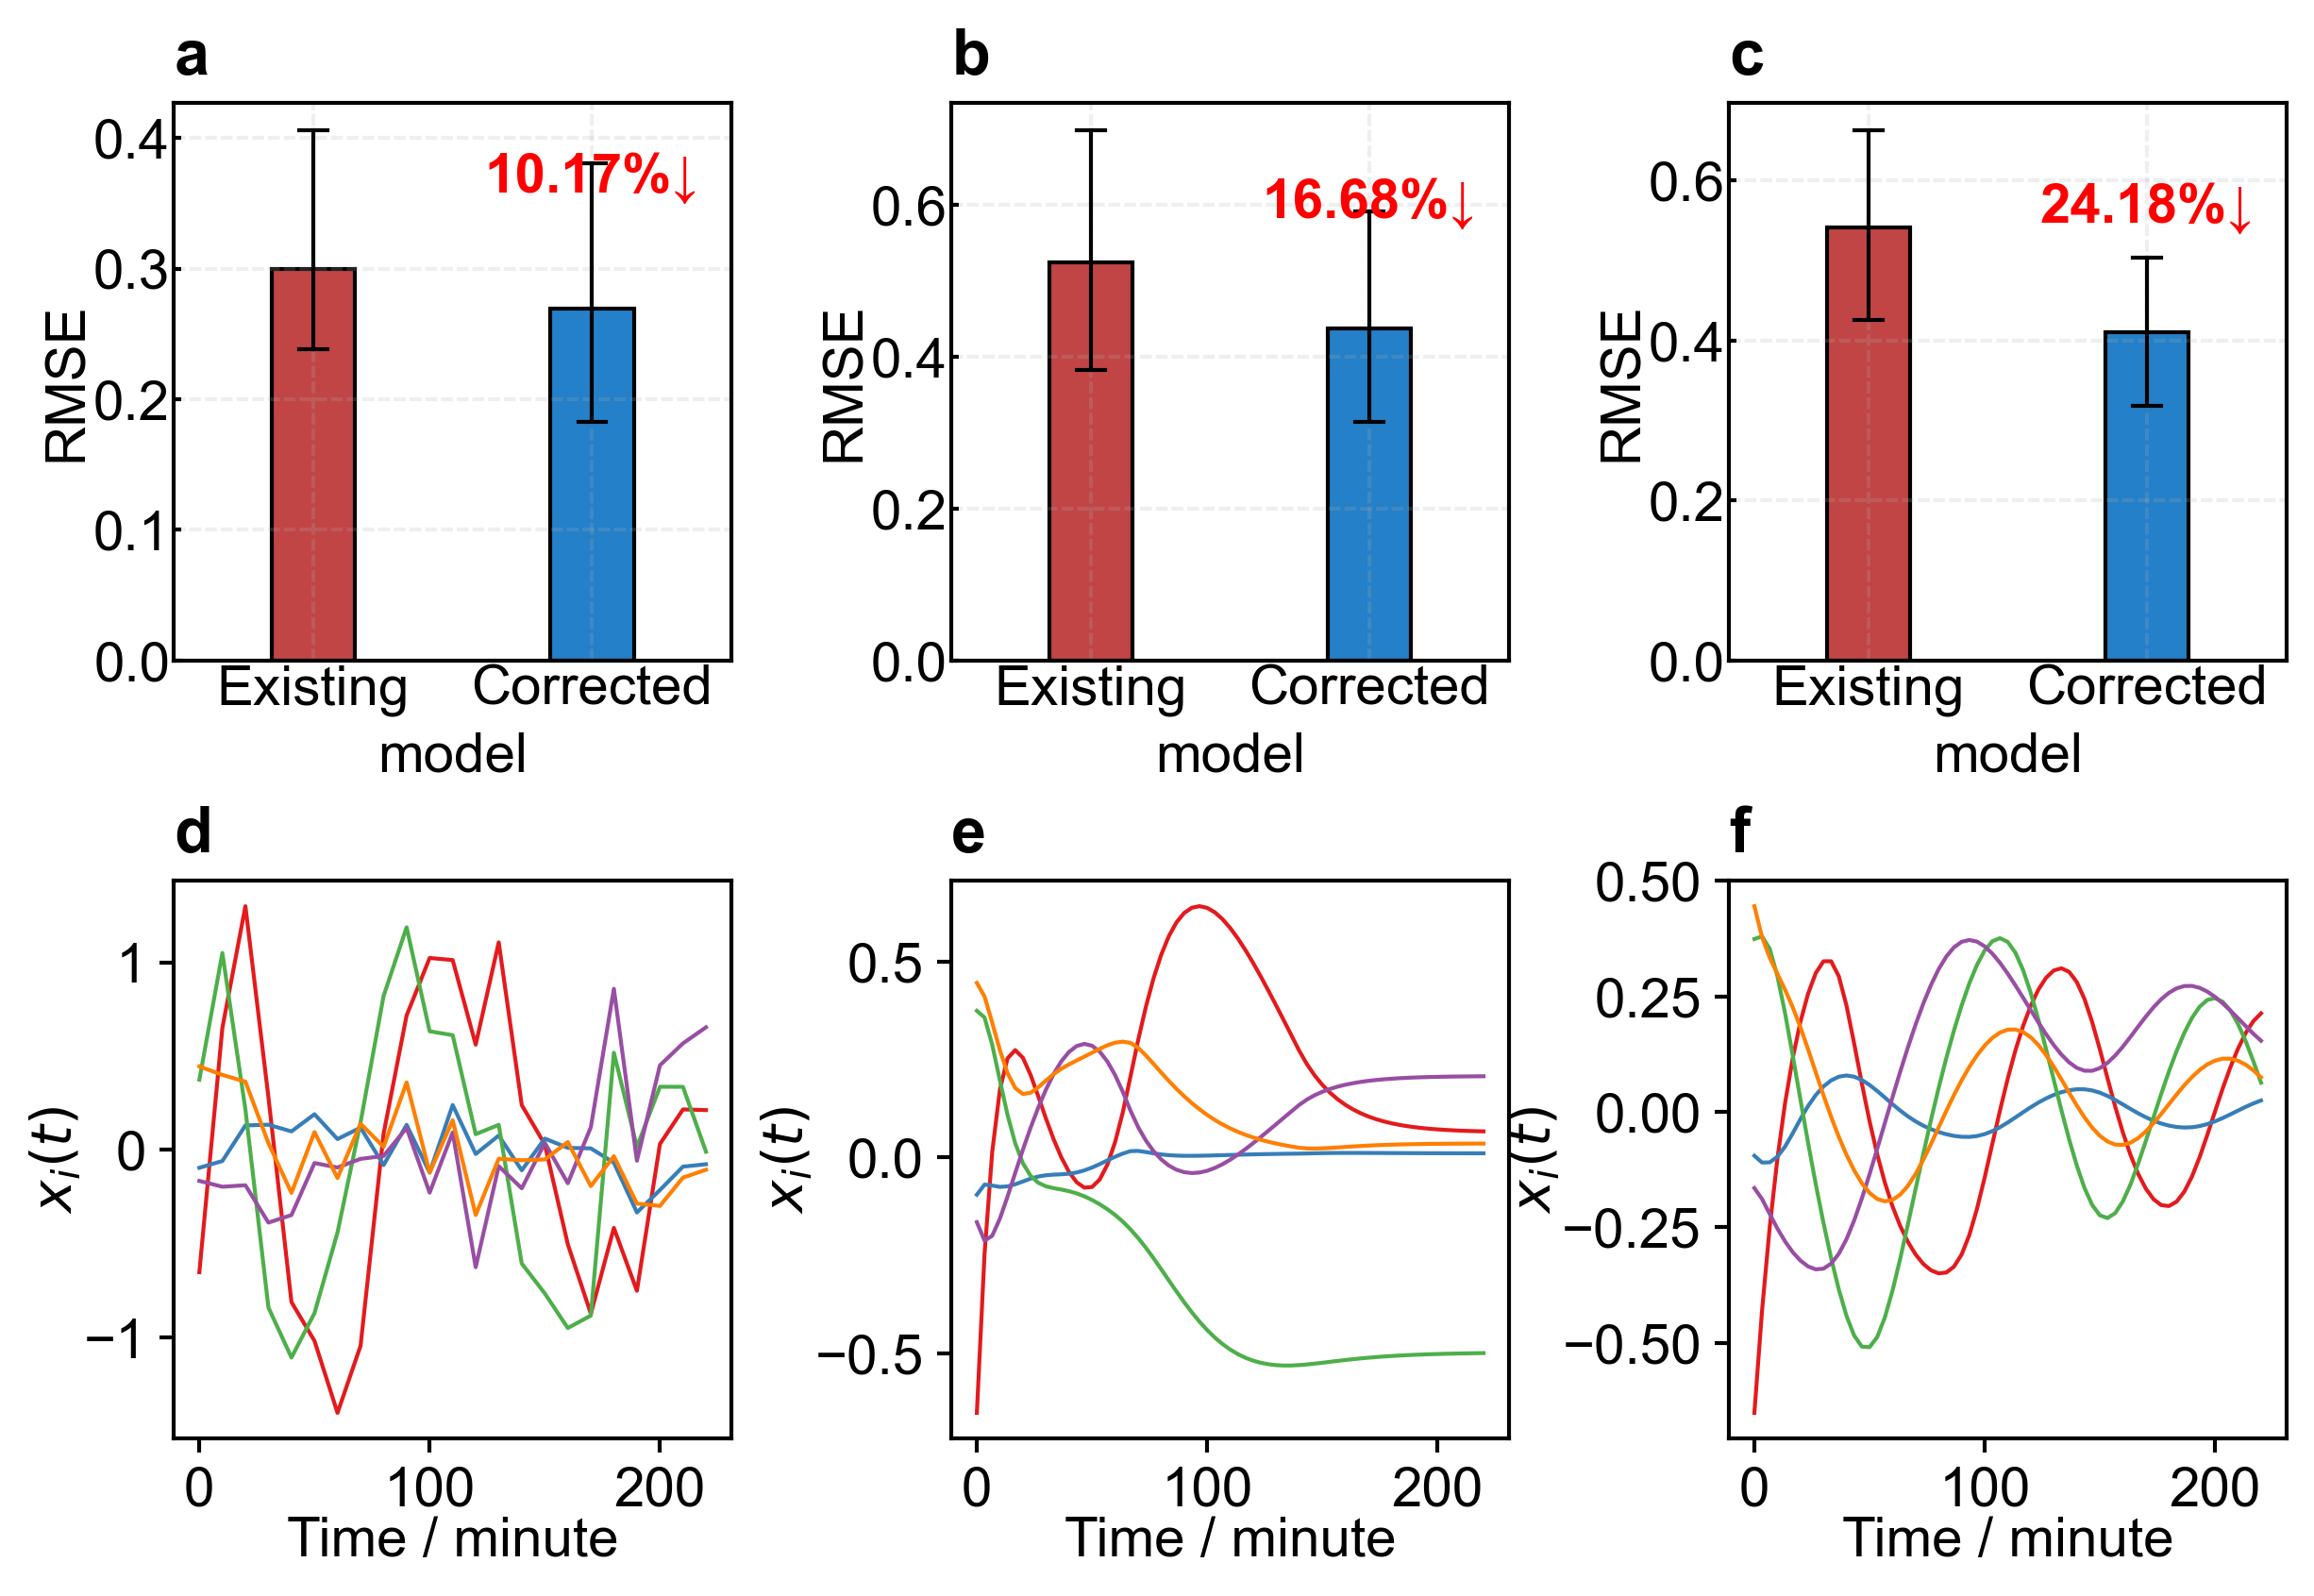

In [167]:
import seaborn as sns
import pandas as pd
from matplotlib.ticker import PercentFormatter, ScalarFormatter

figinfo, fig, axes = get_fig(2, 3, AH=5, A_ratio=1, LM=4, RM=0.5, TM=2.0, BM=2.5, VS=4, fontsize=14, lw=1)
axes = [*axes[3:], *axes[:3]]

# Set20
cmap = plt.get_cmap('Set1')

rollout = RESULT['R_N20_CDC15']
for i in range(V):
    axes[0].plot(10*rollout['time'], rollout['true'][:, i], label='Pred', color=cmap(i))

for i in range(V):
    axes[1].plot(10*rollout['time_all'], rollout['pred_all'][:, i], label='Pred', color=cmap(i))

rollout = RESULT['C_N20_CDC15']
for i in range(V):
    axes[2].plot(10*rollout['time_all'], rollout['pred_all'][:, i], label='Pred', color=cmap(i))

for ax in axes[:3]:
    ax.set_xlabel('Time / minute', labelpad=0)
    ax.set_ylabel('$x_i(t)$', labelpad=0)

result = pd.concat([
    pd.DataFrame({'value': np.sqrt(np.mean(np.square(RESULT['R_N5_CDC15']['true'] - RESULT['R_N5_CDC15']['pred_all'][::N]), axis=0))}).assign(model='Existing'),
    pd.DataFrame({'value': np.sqrt(np.mean(np.square(RESULT['C_N5_CDC15']['true'] - RESULT['C_N5_CDC15']['pred_all'][::N]), axis=0))}).assign(model='Corrected'),
], axis=0)
sns.barplot(result, x='model', y='value', palette=['#d63031', '#0984e3'], ax=axes[3], capsize=0.1, err_kws={'linewidth':1.0, 'color':'black'}, edgecolor='black', width=0.3)
axes[3].set_ylabel('RMSE', labelpad=0)
axes[3].tick_params('y', direction='in', length=2.0, pad=1.0)
axes[3].tick_params('x', length=0.0, pad=1.0)
axes[3].grid('on', alpha=0.2, dashes=[3, 1], zorder=-1)
tmp = result.groupby('model').mean()['value']
axes[3].text(1.0, 1.3*tmp['Corrected'], f'{1 - tmp['Corrected'] / tmp['Existing']:.2%}↓', ha='center', va='bottom', fontsize=14, color='red', fontweight='bold')

result = pd.concat([
    pd.DataFrame({'value': np.sqrt(np.mean(np.square(RESULT['R_N10_CDC15']['true'] - RESULT['R_N10_CDC15']['pred_all'][::N]), axis=0))}).assign(model='Existing'),
    pd.DataFrame({'value': np.sqrt(np.mean(np.square(RESULT['C_N10_CDC15']['true'] - RESULT['C_N10_CDC15']['pred_all'][::N]), axis=0))}).assign(model='Corrected'),
], axis=0)
sns.barplot(result, x='model', y='value', palette=['#d63031', '#0984e3'], ax=axes[4], capsize=0.1, err_kws={'linewidth':1.0, 'color':'black'}, edgecolor='black', width=0.3)
axes[4].set_ylabel('RMSE', labelpad=0)
axes[4].tick_params('y', direction='in', length=2.0, pad=1.0)
axes[4].tick_params('x', length=0.0, pad=1.0)
axes[4].grid('on', alpha=0.2, dashes=[3, 1], zorder=-1)
tmp = result.groupby('model').mean()['value']
axes[4].text(1.0, 1.3*tmp['Corrected'], f'{1 - tmp['Corrected'] / tmp['Existing']:.2%}↓', ha='center', va='bottom', fontsize=14, color='red', fontweight='bold')

result = pd.concat([
    pd.DataFrame({'value': np.sqrt(np.mean(np.square(RESULT['R_N20_CDC15']['true'] - RESULT['R_N20_CDC15']['pred_all'][::N]), axis=0))}).assign(model='Existing'),
    pd.DataFrame({'value': np.sqrt(np.mean(np.square(RESULT['C_N20_CDC15']['true'] - RESULT['C_N20_CDC15']['pred_all'][::N]), axis=0))}).assign(model='Corrected'),
], axis=0)
sns.barplot(result, x='model', y='value', palette=['#d63031', '#0984e3'], ax=axes[5], capsize=0.1, err_kws={'linewidth':1.0, 'color':'black'}, edgecolor='black', width=0.3)
axes[5].set_ylabel('RMSE', labelpad=0)
axes[5].tick_params('y', direction='in', length=2.0, pad=1.0)
axes[5].tick_params('x', length=0.0, pad=1.0)
axes[5].grid('on', alpha=0.2, dashes=[3, 1], zorder=-1)
tmp = result.groupby('model').mean()['value']
axes[5].text(1.0, 1.3*tmp['Corrected'], f'{1 - tmp['Corrected'] / tmp['Existing']:.2%}↓', ha='center', va='bottom', fontsize=14, color='red', fontweight='bold')

# result = pd.concat([
#     pd.DataFrame({'value': np.mean(2 * np.abs(RESULT['R_N20_CDC15']['true'] - RESULT['R_N20_CDC15']['pred_all'][::N]) / (1e-6 + np.abs(RESULT['R_N20_CDC15']['true']) + np.abs(RESULT['R_N20_CDC15']['pred_all'][::N])), axis=0)}).assign(model='Existing'),
#     pd.DataFrame({'value': np.mean(2 * np.abs(RESULT['C_N20_CDC15']['true'] - RESULT['C_N20_CDC15']['pred_all'][::N]) / (1e-6 + np.abs(RESULT['C_N20_CDC15']['true']) + np.abs(RESULT['C_N20_CDC15']['pred_all'][::N])), axis=0)}).assign(model='Corrected'),
# ], axis=0)
# sns.barplot(result, x='model', y='value', palette=['#d63031', '#0984e3'], ax=axes[6], capsize=0.1, err_kws={'linewidth':1.0, 'color':'black'}, edgecolor='black', width=0.3)
# axes[6].set_ylabel('RMSE', labelpad=0)
# axes[6].tick_params('y', direction='in', length=2.0, pad=1.0)
# axes[6].tick_params('x', length=0.0, pad=1.0)
# axes[6].grid('on', alpha=0.2, dashes=[3, 1], zorder=-1)
# tmp = result.groupby('model').mean()['value']
# axes[6].text(1.0, 1.3*tmp['Corrected'], f'{1 - tmp['Corrected'] / tmp['Existing']:.2%}↓', ha='center', va='bottom', fontsize=14, color='red', fontweight='bold')

for idx, ax in enumerate(axes[:3], 3):
    ax.text(0, 1.03, chr(ord('a') + idx), fontsize=16, ha='left', va='bottom', weight='bold', transform=ax.transAxes)

for idx, ax in enumerate(axes[3:], 0):
    ax.text(0, 1.03, chr(ord('a') + idx), fontsize=16, ha='left', va='bottom', weight='bold', transform=ax.transAxes)

fig.savefig('./plot/gene/gene_extrapolation.pdf', dpi=300, transparent=True, bbox_inches='tight')

In [109]:
rollout['time']

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22])

In [111]:
df

,Type1,Type2,Type3,Type4,Type5
time,,,,,
010,-0.216379,0.354758,0.331262,-0.181729,0.138669
030,-0.283822,0.377051,0.372206,-0.145914,0.426064
050,-0.171193,0.385346,0.457102,-0.032285,0.382175
070,-0.124147,0.061152,0.147327,-0.076452,-0.368377
090,-0.189083,-0.011847,0.067133,-0.191216,-0.516062
100,0.081069,-0.113205,-0.069409,0.333001,0.409801
110,-0.057415,0.079332,0.100636,-0.102702,-0.428401
120,0.076993,-0.255689,-0.148239,0.388291,0.577189
130,-0.015263,0.124119,0.025998,-0.203203,-0.470479
